
###  SKU SELECCIONADOS PARA LA SIMULACIÓN

| SKU | Característica | Demanda Promedio | CV (%) | Categoría |
|-----|----------------|------------------|--------|-----------|
| **SKU_073** |  ESTABLE | 462 unid/mes | 21.41 | ALTA |
| **SKU_191** |  ESTABILIDAD MEDIA | 445 unid/mes | 25.98 | ALTA |
| **SKU_041** |  MÁS VARIABLE | 374 unid/mes | 26.21 | ALTA |

**¿Por qué estos?** Representan diferentes niveles de variabilidad en la demanda, lo que permite probar políticas adaptadas a diferentes escenarios.

---

### FLUJO DE TRABAJO

1. **Cargar y explorar datos**
2. **Análisis estadístico descriptivo** de los 3 SKU
3. **Ajustar distribuciones de probabilidad** (Normal, Lognormal, Gamma, Weibull)
4. **Seleccionar mejor distribución** usando tests de bondad de ajuste
5. **Calcular parámetros de inventario** (ROP, SS, EOQ)
6. **SIMULACIÓN MONTE CARLO** (120 meses) para validar política
7. **Análisis de resultados** y métricas de desempeño
8. **Recomendaciones estratégicas**

In [1]:
# ============================================================================
# 1. IMPORTACIONES Y CONFIGURACIÓN
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kstest, shapiro, anderson, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configurar para mostrar más columnas en DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("  Librerías cargadas correctamente")
print("\nLibrerías disponibles:")
print("- pandas (manipulación de datos)")
print("- numpy (cálculos numéricos)")
print("- matplotlib y seaborn (visualización)")
print("- scipy.stats (distribuciones y tests estadísticos)")

  Librerías cargadas correctamente

Librerías disponibles:
- pandas (manipulación de datos)
- numpy (cálculos numéricos)
- matplotlib y seaborn (visualización)
- scipy.stats (distribuciones y tests estadísticos)


In [2]:
# ============================================================================
# 2. CARGAR DATOS DESDE EXCEL
# ============================================================================

#  Rutas de archivos
ruta_excel = "/Users/yedisoncuervo/Desktop/Actividad_GestionCadenas/Documentos/Demandas_Und4.xlsx"

# 📊 Cargar datos
print(" Cargando datos del Excel...\n")
df_demanda = pd.read_excel(ruta_excel, sheet_name="HistoricoDemandas")
df_costos = pd.read_excel(ruta_excel, sheet_name="InfoCostos")

print(f" Datos cargados:")
print(f"   • Histórico de Demandas: {df_demanda.shape[0]} meses × {df_demanda.shape[1]-1} SKUs")
print(f"   • Rango temporal: {df_demanda['month'].min()} a {df_demanda['month'].max()}")
print(f"   • Información de Costos: {df_costos.shape[0]} SKUs")

print("\n" + "="*80)
print("PRIMERAS FILAS DEL HISTÓRICO DE DEMANDA")
print("="*80)
print(df_demanda.head(10))

print("\n" + "="*80)
print("COLUMNAS DISPONIBLES EN COSTOS")
print("="*80)
print(df_costos.columns.tolist())
print("\n" + df_costos[['SKU', 'Categoria_Precio', 'Precio_Venta', 'Costo_Mantenimiento_anual', 'Costo_Pedido_S']].head(10).to_string())

 Cargando datos del Excel...

 Datos cargados:
   • Histórico de Demandas: 120 meses × 200 SKUs
   • Rango temporal: 2016-01 a 2025-12
   • Información de Costos: 200 SKUs

PRIMERAS FILAS DEL HISTÓRICO DE DEMANDA
     month  SKU_001  SKU_002  SKU_003  SKU_004  SKU_005  SKU_006  SKU_007  \
0  2016-01      226      220        6        0      609       64      208   
1  2016-02      216      177       18        0      406       74      330   
2  2016-03      203      260        1        0      363       57      320   
3  2016-04      212      159        0        0      487       60      329   
4  2016-05      198      155       12        5      475       87      380   
5  2016-06      224      234        5        0      601       64      457   
6  2016-07      205      240        1        0      494       61      342   
7  2016-08      213      253        3        0      596       65      297   
8  2016-09      202      244        4        8      355       61      259   
9  2016-10      2

In [3]:
# ============================================================================
# 3. SELECCIÓN DE SKU Y ANÁLISIS EXPLORATORIO
# ============================================================================

# 🎯 SKU SELECCIONADOS PARA LA SIMULACIÓN
skus_seleccionados = ['SKU_073', 'SKU_191', 'SKU_041']

print("\n" + "="*80)
print("SKU SELECCIONADOS PARA LA SIMULACIÓN")
print("="*80)

# Extraer datos de los SKU seleccionados
datos_seleccionados = {}

for sku in skus_seleccionados:
    # Demanda histórica
    demanda = df_demanda[sku].values
    
    # Información de costos
    info_costo = df_costos[df_costos['SKU'] == sku].iloc[0]
    
    datos_seleccionados[sku] = {
        'demanda': demanda,
        'precio_venta': info_costo['Precio_Venta'],
        'costo_mantenimiento': info_costo['Costo_Mantenimiento_anual'],
        'costo_pedido': info_costo['Costo_Pedido_S'],
        'categoria_precio': info_costo['Categoria_Precio']
    }

# 📊 ANÁLISIS ESTADÍSTICO DESCRIPTIVO
print("\n" + "-"*80)
print("ESTADÍSTICAS DESCRIPTIVAS DE DEMANDA")
print("-"*80 + "\n")

estadisticas = []

for sku in skus_seleccionados:
    demanda = datos_seleccionados[sku]['demanda']
    
    stats_dict = {
        'SKU': sku,
        'Media': np.mean(demanda),
        'Desv. Est.': np.std(demanda, ddof=1),
        'CV (%)': (np.std(demanda, ddof=1) / np.mean(demanda)) * 100,
        'Min': np.min(demanda),
        'Q1 (25%)': np.percentile(demanda, 25),
        'Mediana': np.median(demanda),
        'Q3 (75%)': np.percentile(demanda, 75),
        'Max': np.max(demanda),
        'Asimetría': stats.skew(demanda),
        'Curtosis': stats.kurtosis(demanda)
    }
    estadisticas.append(stats_dict)

df_stats = pd.DataFrame(estadisticas)

# Mostrar con formato
print(df_stats.to_string(index=False))

print("\n" + "-"*80)
print("INTERPRETACIÓN:")
print("-"*80)
print("""
• CV (Coeficiente de Variación): Mide variabilidad relativa
  - CV < 25%: Demanda estable
  - CV 25-35%: Demanda moderada
  - CV > 35%: Demanda muy variable

• Asimetría (Skewness): 
  - ≈ 0: Distribución simétrica
  - > 0: Cola derecha (valores altos ocasionales)
  - < 0: Cola izquierda (valores bajos ocasionales)

• Curtosis (Kurtosis):
  - ≈ 0: Distribución normal
  - > 0: Colas más pesadas (outliers)
  - < 0: Colas más ligeras
""")

#  Información de costos
print("\n" + "-"*80)
print("INFORMACIÓN DE COSTOS Y PARÁMETROS")
print("-"*80 + "\n")

info_costos = []
for sku in skus_seleccionados:
    info_costos.append({
        'SKU': sku,
        'Precio Venta': f"${datos_seleccionados[sku]['precio_venta']:.2f}",
        'Costo Mantenimiento Anual': f"${datos_seleccionados[sku]['costo_mantenimiento']:.2f}",
        'Costo Pedido (S)': f"${datos_seleccionados[sku]['costo_pedido']:.2f}",
        'Categoría Precio': datos_seleccionados[sku]['categoria_precio']
    })

df_info = pd.DataFrame(info_costos)
print(df_info.to_string(index=False))


SKU SELECCIONADOS PARA LA SIMULACIÓN

--------------------------------------------------------------------------------
ESTADÍSTICAS DESCRIPTIVAS DE DEMANDA
--------------------------------------------------------------------------------

    SKU      Media  Desv. Est.    CV (%)  Min  Q1 (25%)  Mediana  Q3 (75%)  Max  Asimetría  Curtosis
SKU_073 461.858333   98.893398 21.412063  199    386.50    453.5    549.25  700  -0.033495 -0.649062
SKU_191 445.166667  115.663401 25.982044  196    361.75    455.0    525.00  804   0.150227  0.071297
SKU_041 373.933333   98.001006 26.208149  141    301.75    375.0    435.25  677   0.198252  0.166529

--------------------------------------------------------------------------------
INTERPRETACIÓN:
--------------------------------------------------------------------------------

• CV (Coeficiente de Variación): Mide variabilidad relativa
  - CV < 25%: Demanda estable
  - CV 25-35%: Demanda moderada
  - CV > 35%: Demanda muy variable

• Asimetría (Skewne


GRÁFICAS 1 Y 2: SERIES TEMPORALES E HISTOGRAMAS DE DEMANDA



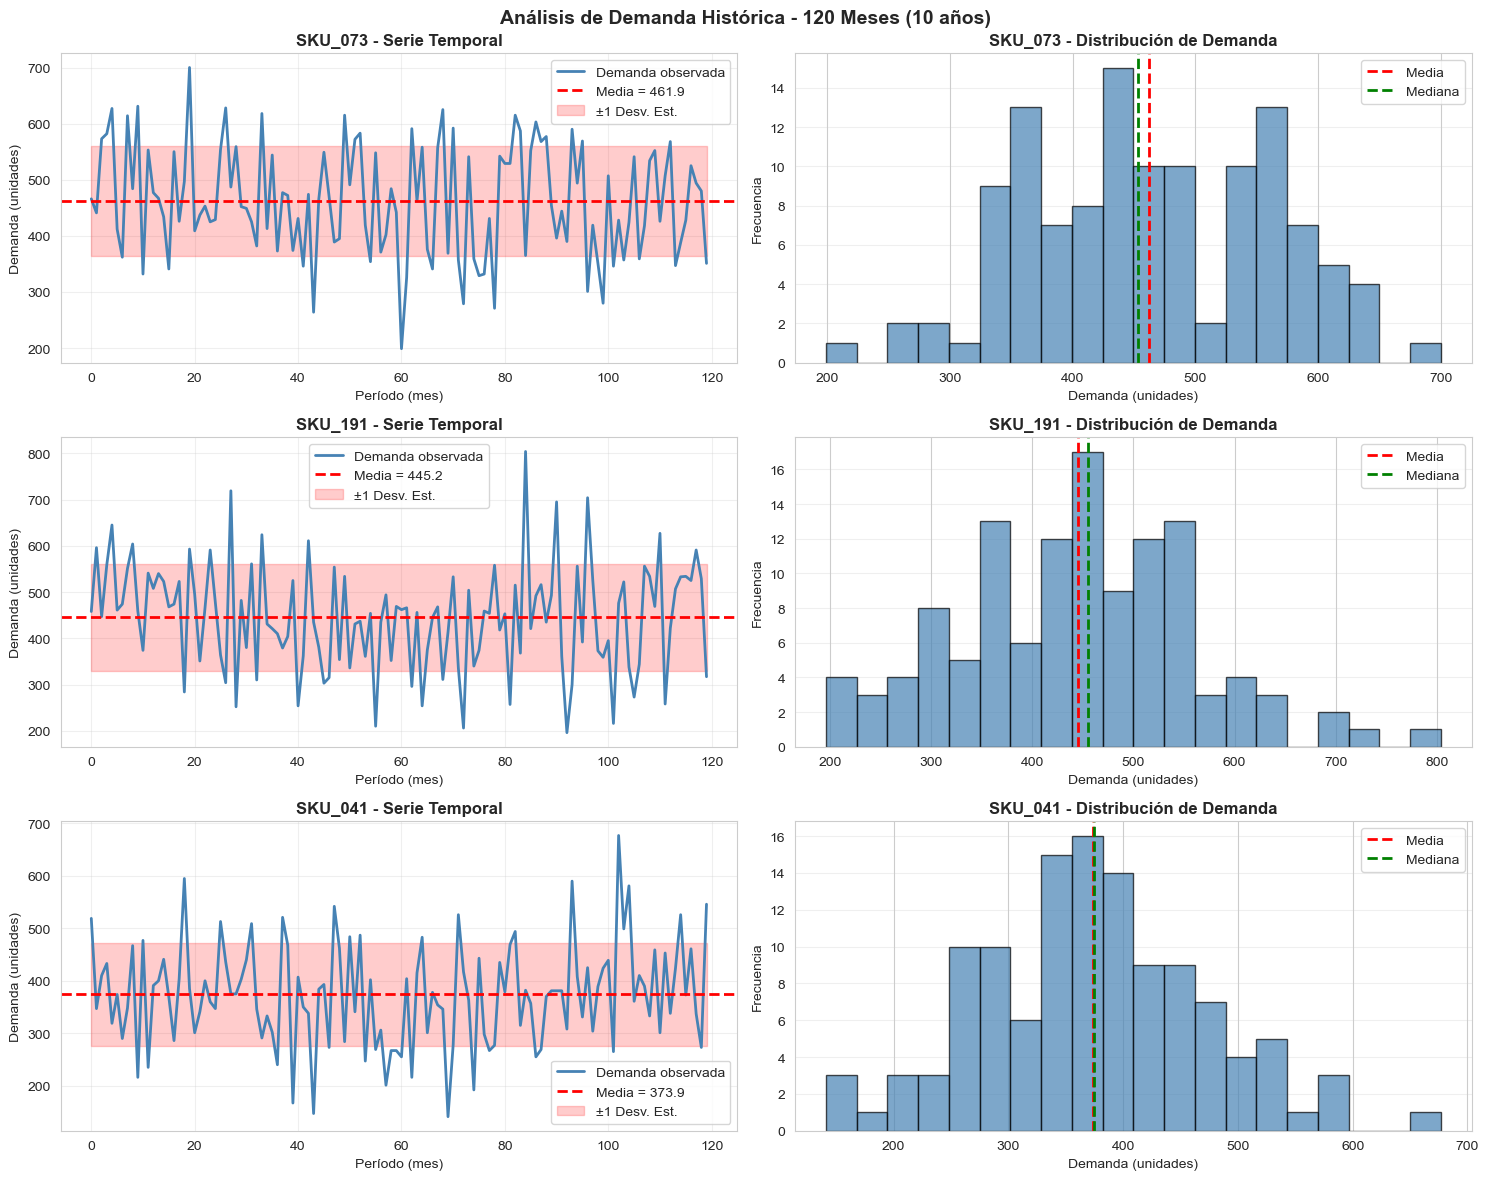

 Gráficas guardadas: 01_Series_Temporales.png


In [4]:
# ============================================================================
# 4. VISUALIZACIÓN DE SERIES TEMPORALES Y DISTRIBUCIONES
# ============================================================================

print("\n" + "="*80)
print("GRÁFICAS 1 Y 2: SERIES TEMPORALES E HISTOGRAMAS DE DEMANDA")
print("="*80 + "\n")

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Análisis de Demanda Histórica - 120 Meses (10 años)', fontsize=14, fontweight='bold')

for idx, sku in enumerate(skus_seleccionados):
    demanda = datos_seleccionados[sku]['demanda']
    
    # Gráfica 1: Serie temporal
    ax1 = axes[idx, 0]
    ax1.plot(demanda, linewidth=2, color='steelblue', label='Demanda observada')
    ax1.axhline(np.mean(demanda), color='red', linestyle='--', linewidth=2, label=f'Media = {np.mean(demanda):.1f}')
    ax1.fill_between(range(len(demanda)), 
                      np.mean(demanda) - np.std(demanda), 
                      np.mean(demanda) + np.std(demanda), 
                      alpha=0.2, color='red', label='±1 Desv. Est.')
    ax1.set_title(f'{sku} - Serie Temporal', fontweight='bold')
    ax1.set_xlabel('Período (mes)')
    ax1.set_ylabel('Demanda (unidades)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfica 2: Histograma
    ax2 = axes[idx, 1]
    ax2.hist(demanda, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.axvline(np.mean(demanda), color='red', linestyle='--', linewidth=2, label=f'Media')
    ax2.axvline(np.median(demanda), color='green', linestyle='--', linewidth=2, label=f'Mediana')
    ax2.set_title(f'{sku} - Distribución de Demanda', fontweight='bold')
    ax2.set_xlabel('Demanda (unidades)')
    ax2.set_ylabel('Frecuencia')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/Users/yedisoncuervo/Desktop/Actividad_GestionCadenas/src/01_Series_Temporales.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Gráficas guardadas: 01_Series_Temporales.png")

In [ ]:
# ============================================================================
# 5. AJUSTE DE DISTRIBUCIONES DE PROBABILIDAD
# ============================================================================

print("\n" + "="*80)
print("AJUSTE DE DISTRIBUCIONES - PRUEBAS DE BONDAD DE AJUSTE")
print("="*80 + "\n")

print("""
METODOLOGÍA:
Vamos a probar 5 distribuciones de probabilidad y elegir la MEJOR usando:

1. NORMAL (Gaussian): Curva de campana clásica
2. LOGNORMAL: Normal pero de los logaritmos (valores > 0)
3. GAMMA: Flexible, buena para datos con asimetría
4. WEIBULL: Flexible, modelar tiempo de falla/demanda
5. EXPONENCIAL: Para demanda intermitente

Tests de bondad de ajuste:
- Kolmogorov-Smirnov (KS): Compara CDFs
- Anderson-Darling (AD): Más sensible a colas
- Shapiro-Wilk (SW): Muy confiable para n < 5000
- Chi-cuadrado: Para datos agrupados
""")

# Función para ajustar distribuciones
def ajustar_distribuciones(demanda, nombre_sku):
    """
    Ajusta múltiples distribuciones a los datos y retorna los parámetros
    
    Parameters:
    -----------
    demanda : array
        Series de demanda histórica
    nombre_sku : str
        Nombre del SKU para identificar
        
    Returns:
    --------
    dict : Diccionario con parámetros y tests de ajuste
    """
    
    print(f"\n Ajustando distribuciones para {nombre_sku}...")
    print("-" * 80)
    
    resultados = {}
    
    # 1. DISTRIBUCIÓN NORMAL
    try:
        mu_norm, sigma_norm = stats.norm.fit(demanda)
        ks_stat_norm, ks_p_norm = kstest(demanda, lambda x: stats.norm.cdf(x, mu_norm, sigma_norm))
        ad_result_norm = anderson(demanda, dist='norm')
        sw_stat_norm, sw_p_norm = shapiro(demanda)
        
        resultados['Normal'] = {
            'params': {'mu': mu_norm, 'sigma': sigma_norm},
            'ks_stat': ks_stat_norm,
            'ks_pvalue': ks_p_norm,
            'ad_stat': ad_result_norm.statistic,
            'sw_stat': sw_stat_norm,
            'sw_pvalue': sw_p_norm,
            'formula': f'μ={mu_norm:.2f}, σ={sigma_norm:.2f}'
        }
    except:
        resultados['Normal'] = {'error': 'No se pudo ajustar'}
    
    # 2. DISTRIBUCIÓN LOGNORMAL
    try:
        shape_ln, loc_ln, scale_ln = stats.lognorm.fit(demanda, floc=0)
        ks_stat_ln, ks_p_ln = kstest(demanda, lambda x: stats.lognorm.cdf(x, shape_ln, loc_ln, scale_ln))
        sw_stat_ln, sw_p_ln = shapiro(np.log(demanda))
        
        resultados['Lognormal'] = {
            'params': {'shape': shape_ln, 'scale': scale_ln},
            'ks_stat': ks_stat_ln,
            'ks_pvalue': ks_p_ln,
            'sw_stat': sw_stat_ln,
            'sw_pvalue': sw_p_ln,
            'formula': f'σ={shape_ln:.2f}, μ={np.log(scale_ln):.2f}'
        }
    except:
        resultados['Lognormal'] = {'error': 'No se pudo ajustar'}
    
    # 3. DISTRIBUCIÓN GAMMA
    try:
        shape_ga, loc_ga, scale_ga = stats.gamma.fit(demanda, floc=0)
        ks_stat_ga, ks_p_ga = kstest(demanda, lambda x: stats.gamma.cdf(x, shape_ga, loc_ga, scale_ga))
        ad_result_ga = anderson(demanda / scale_ga, dist='expon')
        
        resultados['Gamma'] = {
            'params': {'shape': shape_ga, 'scale': scale_ga},
            'ks_stat': ks_stat_ga,
            'ks_pvalue': ks_p_ga,
            'ad_stat': ad_result_ga.statistic,
            'formula': f'α={shape_ga:.2f}, β={scale_ga:.2f}'
        }
    except:
        resultados['Gamma'] = {'error': 'No se pudo ajustar'}
    
    # 4. DISTRIBUCIÓN WEIBULL
    try:
        shape_wb, loc_wb, scale_wb = stats.weibull_min.fit(demanda, floc=0)
        ks_stat_wb, ks_p_wb = kstest(demanda, lambda x: stats.weibull_min.cdf(x, shape_wb, loc_wb, scale_wb))
        
        resultados['Weibull'] = {
            'params': {'shape': shape_wb, 'scale': scale_wb},
            'ks_stat': ks_stat_wb,
            'ks_pvalue': ks_p_wb,
            'formula': f'k={shape_wb:.2f}, λ={scale_wb:.2f}'
        }
    except:
        resultados['Weibull'] = {'error': 'No se pudo ajustar'}
    
    # 5. DISTRIBUCIÓN EXPONENCIAL
    try:
        lambda_exp = 1 / np.mean(demanda)
        ks_stat_exp, ks_p_exp = kstest(demanda, lambda x: stats.expon.cdf(x, scale=1/lambda_exp))
        
        resultados['Exponencial'] = {
            'params': {'lambda': lambda_exp},
            'ks_stat': ks_stat_exp,
            'ks_pvalue': ks_p_exp,
            'formula': f'λ={lambda_exp:.4f}'
        }
    except:
        resultados['Exponencial'] = {'error': 'No se pudo ajustar'}
    
    return resultados

# Ejecutar ajustes para cada SKU
resultados_ajustes = {}

for sku in skus_seleccionados:
    demanda = datos_seleccionados[sku]['demanda']
    resultados_ajustes[sku] = ajustar_distribuciones(demanda, sku)

# Mostrar resultados en tabla comparativa
print("\n" + "="*80)
print("RESULTADOS DE AJUSTE - TEST KOLMOGOROV-SMIRNOV (KS)")
print("="*80)
print("(Valores p > 0.05 indican buen ajuste)\n")

for sku in skus_seleccionados:
    print(f"\n🔹 {sku}")
    print("-" * 80)
    
    tabla_resultados = []
    for dist_name, dist_info in resultados_ajustes[sku].items():
        if 'error' not in dist_info:
            tabla_resultados.append({
                'Distribución': dist_name,
                'KS Estadístico': f"{dist_info['ks_stat']:.4f}",
                'P-valor KS': f"{dist_info['ks_pvalue']:.4f}",
                'Parámetros': dist_info['formula'],
                'Ajuste': ' BUENO' if dist_info['ks_pvalue'] > 0.05 else ' POBRE'
            })
        else:
            tabla_resultados.append({
                'Distribución': dist_name,
                'KS Estadístico': 'Error',
                'P-valor KS': 'Error',
                'Parámetros': 'N/A',
                'Ajuste': ' ERROR'
            })
    
    df_tabla = pd.DataFrame(tabla_resultados)
    print(df_tabla.to_string(index=False))


AJUSTE DE DISTRIBUCIONES - PRUEBAS DE BONDAD DE AJUSTE


METODOLOGÍA:
Vamos a probar 5 distribuciones de probabilidad y elegir la MEJOR usando:

1. NORMAL (Gaussian): Curva de campana clásica
2. LOGNORMAL: Normal pero de los logaritmos (valores > 0)
3. GAMMA: Flexible, buena para datos con asimetría
4. WEIBULL: Flexible, modelar tiempo de falla/demanda
5. EXPONENCIAL: Para demanda intermitente

Tests de bondad de ajuste:
- Kolmogorov-Smirnov (KS): Compara CDFs
- Anderson-Darling (AD): Más sensible a colas
- Shapiro-Wilk (SW): Muy confiable para n < 5000
- Chi-cuadrado: Para datos agrupados


📊 Ajustando distribuciones para SKU_073...
--------------------------------------------------------------------------------

📊 Ajustando distribuciones para SKU_191...
--------------------------------------------------------------------------------

📊 Ajustando distribuciones para SKU_041...
--------------------------------------------------------------------------------

RESULTADOS DE AJUSTE - TE

In [ ]:
# ============================================================================
# 6. VISUALIZACIÓN DE DISTRIBUCIONES AJUSTADAS
# ============================================================================

print("\n" + "="*80)
print("GRÁFICAS 3: DISTRIBUCIONES AJUSTADAS VS DATOS REALES")
print("="*80 + "\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ajuste de Distribuciones de Probabilidad - Histograma + Curvas Teóricas', 
             fontsize=14, fontweight='bold')

for idx, sku in enumerate(skus_seleccionados):
    demanda = datos_seleccionados[sku]['demanda']
    ax = axes[idx]
    
    # Histograma normalizado
    n, bins, patches = ax.hist(demanda, bins=20, density=True, alpha=0.6, 
                               color='steelblue', edgecolor='black', label='Datos reales')
    
    # Rango para graficar las distribuciones ajustadas
    x = np.linspace(demanda.min(), demanda.max(), 100)
    
    # Normal
    try:
        params_norm = resultados_ajustes[sku]['Normal']['params']
        pdf_norm = stats.norm.pdf(x, params_norm['mu'], params_norm['sigma'])
        ax.plot(x, pdf_norm, 'r-', linewidth=2, label=f"Normal")
    except:
        pass
    
    # Lognormal
    try:
        params_ln = resultados_ajustes[sku]['Lognormal']['params']
        pdf_ln = stats.lognorm.pdf(x, params_ln['shape'], scale=params_ln['scale'])
        ax.plot(x, pdf_ln, 'g-', linewidth=2, label=f"Lognormal")
    except:
        pass
    
    # Gamma
    try:
        params_ga = resultados_ajustes[sku]['Gamma']['params']
        pdf_ga = stats.gamma.pdf(x, params_ga['shape'], scale=params_ga['scale'])
        ax.plot(x, pdf_ga, 'b-', linewidth=2, label=f"Gamma")
    except:
        pass
    
    # Weibull
    try:
        params_wb = resultados_ajustes[sku]['Weibull']['params']
        pdf_wb = stats.weibull_min.pdf(x, params_wb['shape'], scale=params_wb['scale'])
        ax.plot(x, pdf_wb, 'm-', linewidth=2, label=f"Weibull")
    except:
        pass
    
    ax.set_title(f'{sku}', fontweight='bold')
    ax.set_xlabel('Demanda (unidades)')
    ax.set_ylabel('Densidad de Probabilidad')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/yedisoncuervo/Desktop/Actividad_GestionCadenas/src/02_Distribuciones_Ajustadas.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(" Gráficas guardadas: 02_Distribuciones_Ajustadas.png")

In [ ]:
# ============================================================================
# 7. SELECCIONAR MEJOR DISTRIBUCIÓN Y ALMACENAR PARÁMETROS
# ============================================================================

print("\n" + "="*80)
print("SELECCIÓN DE MEJOR DISTRIBUCIÓN POR SKU")
print("="*80 + "\n")

# Diccionario para guardar las mejores distribuciones
distribucion_seleccionada = {}

for sku in skus_seleccionados:
    print(f"\\n🎯 {sku}: Determinando mejor distribución...")
    
    # Encontrar distribución con mayor p-valor KS (mejor ajuste)
    mejor_dist = None
    mejor_p = -1
    
    for dist_name, dist_info in resultados_ajustes[sku].items():
        if 'ks_pvalue' in dist_info and dist_info['ks_pvalue'] > mejor_p:
            mejor_p = dist_info['ks_pvalue']
            mejor_dist = dist_name
    
    if mejor_dist:
        distribucion_seleccionada[sku] = {
            'nombre': mejor_dist,
            'params': resultados_ajustes[sku][mejor_dist]['params'],
            'ks_pvalue': mejor_p,
            'calidad': ' EXCELENTE' if mejor_p > 0.10 else ('🟡 BUENA' if mejor_p > 0.05 else '⚠️ ACEPTABLE')
        }
        print(f"   Mejor: {mejor_dist} (p-valor = {mejor_p:.4f})")
        print(f"   Parámetros: {distribucion_seleccionada[sku]['params']}")
    else:
        print(f"   ⚠️ No se encontró distribución válida")

# Mostrar resumen
print("\n" + "="*80)
print("RESUMEN DE DISTRIBUCIONES SELECCIONADAS")
print("="*80 + "\n")

resumen_distribuciones = []
for sku in skus_seleccionados:
    if sku in distribucion_seleccionada:
        resumen_distribuciones.append({
            'SKU': sku,
            'Distribución': distribucion_seleccionada[sku]['nombre'],
            'P-valor KS': f"{distribucion_seleccionada[sku]['ks_pvalue']:.4f}",
            'Calidad': distribucion_seleccionada[sku]['calidad']
        })

df_resumen_dist = pd.DataFrame(resumen_distribuciones)
print(df_resumen_dist.to_string(index=False))

In [ ]:
# ============================================================================
# 8. CÁLCULO DE PARÁMETROS DE POLÍTICA DE INVENTARIO
# ============================================================================

print("\n" + "="*80)
print("CÁLCULO DE PARÁMETROS DE INVENTARIO - MODELO EOQ CON PUNTO DE REORDEN")
print("="*80 + "\n")

print("""
FÓRMULAS UTILIZADAS:

1. DEMANDA DIARIA PROMEDIO (d):
   d = Demanda promedio mensual / 30 días
   
   Necesaria para ajustar el tiempo de entrega a días.

2. STOCK DE SEGURIDAD (SS):
   SS = Z(α) × σ_L
   
   donde:
   - Z(α) = Factor de servicio (97% → Z = 1.88)
   - σ_L = Desviación estándar de demanda durante tiempo de entrega
   
   El SS protege contra demanda inesperada durante el lead time.

3. PUNTO DE REORDEN (ROP):
   ROP = (d × L) + SS
   
   donde:
   - d = Demanda diaria promedio
   - L = Tiempo de entrega (días)
   
   Cuando el inventario cae a ROP, se hace un pedido nuevo.

4. CANTIDAD ECONÓMICA DE PEDIDO (EOQ):
   EOQ = √(2 × D × S / H)
   
   donde:
   - D = Demanda anual (unidades)
   - S = Costo de pedido ($)
   - H = Costo de mantenimiento anual ($)
   
   Equilibra costos de pedido vs costos de mantenimiento.

5. COSTO TOTAL ANUAL:
   CT = (D/Q) × S + (Q/2) × H + D × C
   
   donde:
   - (D/Q) × S = Costo anual de pedidos
   - (Q/2) × H = Costo anual de mantenimiento
   - D × C = Costo de producto (constante)
""")

# ============================================================
# PARÁMETROS PARA EL CÁLCULO
# ============================================================

# Factor de servicio para 97% de nivel de confianza
Z_servicio_97 = 1.88  # Valor de tabla normal estándar

# Tiempos de entrega según categoría (todos son ALTA)
# ALTA: 10-25 días, usaremos valor promedio = 17.5 días
tiempos_entrega = {
    'SKU_073': 17.5,
    'SKU_191': 17.5,
    'SKU_041': 17.5
}

print(f"\\nNivel de Servicio Requerido: 97%")
print(f"Factor Z (α=0.03): {Z_servicio_97}")
print(f"Tiempos de Entrega: {list(tiempos_entrega.values())[0]} días (categoría ALTA: 10-25 días)")

# Función para calcular parámetros
def calcular_parametros_inventario(sku, demanda_historica, Z, L_dias):
    \"\"\"
    Calcula parámetros de inventario (ROP, SS, EOQ, CT)
    
    Parameters:
    -----------
    sku : str
        Código del SKU
    demanda_historica : array
        Array con demanda histórica
    Z : float
        Factor de servicio (nivel de confianza)
    L_dias : float
        Tiempo de entrega en días
        
    Returns:
    --------
    dict : Parámetros calculados
    \"\"\"
    
    # Demandas
    d_mensual = np.mean(demanda_historica)
    d_anual = d_mensual * 12
    d_diaria = d_mensual / 30
    
    # Desviación estándar
    sigma = np.std(demanda_historica, ddof=1)
    
    # Desviación estándar durante tiempo de entrega (aprox: sigma * sqrt(L/30))
    sigma_L = sigma * np.sqrt(L_dias / 30)
    
    # Stock de Seguridad
    SS = Z * sigma_L
    
    # Punto de Reorden
    ROP = (d_diaria * L_dias) + SS
    
    # Cantidad Económica de Pedido (EOQ)
    S = datos_seleccionados[sku]['costo_pedido']  # Costo de pedido
    H = datos_seleccionados[sku]['costo_mantenimiento']  # Costo anual mantenimiento
    
    EOQ = np.sqrt((2 * d_anual * S) / H)
    
    # Costo Total Anual (aproximado, sin costo de producto)
    CT_pedidos = (d_anual / EOQ) * S
    CT_mantenimiento = (EOQ / 2) * H
    CT_total = CT_pedidos + CT_mantenimiento
    
    # Número aproximado de pedidos por año
    num_pedidos_anual = d_anual / EOQ
    
    return {
        'demanda_diaria': d_diaria,
        'demanda_mensual': d_mensual,
        'demanda_anual': d_anual,
        'desv_estandar': sigma,
        'desv_estandar_L': sigma_L,
        'stock_seguridad': SS,
        'punto_reorden': ROP,
        'EOQ': EOQ,
        'costo_pedidos_anual': CT_pedidos,
        'costo_mantenimiento_anual': CT_mantenimiento,
        'costo_total_anual': CT_total,
        'num_pedidos_anual': num_pedidos_anual,
        'dias_entre_pedidos': 365 / num_pedidos_anual
    }

# Calcular para cada SKU
parametros_inventario = {}

for sku in skus_seleccionados:
    demanda = datos_seleccionados[sku]['demanda']
    L = tiempos_entrega[sku]
    
    parametros_inventario[sku] = calcular_parametros_inventario(
        sku, demanda, Z_servicio_97, L
    )

# Mostrar en tabla
print("\n" + "="*80)
print("RESUMEN DE PARÁMETROS DE INVENTARIO")
print("="*80 + "\n")

tabla_parametros = []
for sku in skus_seleccionados:
    p = parametros_inventario[sku]
    tabla_parametros.append({
        'SKU': sku,
        'Demanda Mensual': f"{p['demanda_mensual']:.1f}",
        'Demanda Anual': f"{p['demanda_anual']:.0f}",
        'Desv. Estándar': f"{p['desv_estandar']:.2f}",
        'Stock Seguridad': f"{p['stock_seguridad']:.1f}",
        'Punto Reorden': f"{p['punto_reorden']:.1f}",
        'EOQ': f"{p['EOQ']:.0f}",
        'Pedidos/Año': f"{p['num_pedidos_anual']:.1f}",
        'Días entre Pedidos': f"{p['dias_entre_pedidos']:.1f}"
    })

df_param = pd.DataFrame(tabla_parametros)
print(df_param.to_string(index=False))

# Tabla de costos
print("\n" + "-"*80)
print("ANÁLISIS DE COSTOS (Costo de Pedidos + Costo de Mantenimiento)")
print("-"*80 + "\n")

tabla_costos = []
for sku in skus_seleccionados:
    p = parametros_inventario[sku]
    tabla_costos.append({
        'SKU': sku,
        'Costo Pedidos/Año': f"${p['costo_pedidos_anual']:.2f}",
        'Costo Mantenimiento/Año': f"${p['costo_mantenimiento_anual']:.2f}",
        'Costo Total Anual': f"${p['costo_total_anual']:.2f}",
        'Inventario Promedio': f"{p['EOQ']/2 + p['stock_seguridad']:.0f} unid."
    })

df_costos_param = pd.DataFrame(tabla_costos)
print(df_costos_param.to_string(index=False))

In [ ]:
# ============================================================================
# 9. SIMULACIÓN MONTE CARLO - VALIDACIÓN DE POLÍTICA DE INVENTARIO
# ============================================================================

print("\n" + "="*80)
print("SIMULACIÓN MONTE CARLO - 120 PERÍODOS DE SIMULACIÓN")
print("="*80 + "\n")

print("""
DINÁMICA DE LA SIMULACIÓN:

Para cada período (mes) simulamos:

1. GENERAR DEMANDA ALEATORIA
   └─> Usar la distribución ajustada + parámetros
   
2. SERVIR DEMANDA
   └─> Si Inventario >= Demanda → Servir, reducir inventario
   └─> Si Inventario < Demanda → Faltante (quebranto de venta)
   
3. VERIFICAR PUNTO DE REORDEN
   └─> Si Inventario ≤ ROP → Hacer pedido de cantidad EOQ
   
4. PROCESAR ENTREGAS
   └─> Productos en tránsito llegan después de L_dias
   └─> Aumentar inventario cuando llega el pedido
   
5. REGISTRAR MÉTRICAS
   └─> Nivel de inventario al final del período
   └─> Número de faltantes
   └─> Número de pedidos
   └─> Costo del período

Objetivo: ¿Se alcanza 97% de nivel de servicio?
""")

def simular_inventario(sku, num_periodos=120, seed=42):
    \"\"\"
    Simulación Monte Carlo del sistema de inventario
    
    Parameters:
    -----------
    sku : str
        Código del SKU a simular
    num_periodos : int
        Número de períodos a simular (default 120 meses)
    seed : int
        Semilla para reproducibilidad
        
    Returns:
    --------
    dict : Resultados de la simulación
    \"\"\"
    
    np.random.seed(seed)
    
    # Obtener parámetros
    p = parametros_inventario[sku]
    dist = distribucion_seleccionada[sku]['nombre']
    dist_params = distribucion_seleccionada[sku]['params']
    
    # Parámetros operacionales
    ROP = p['punto_reorden']
    EOQ = p['EOQ']
    L = tiempos_entrega[sku]
    
    # Variables de simulación
    inventario = EOQ * 1.5  # Inventario inicial
    pedidos_en_transito = {}  # {dia_llegada: cantidad}
    
    # Registros
    registros = []
    
    # Generador de demanda según distribución ajustada
    if dist == 'Normal':
        demanda_gen = lambda: max(0, np.random.normal(dist_params['mu'], dist_params['sigma']))
    elif dist == 'Lognormal':
        demanda_gen = lambda: np.random.lognormal(np.log(dist_params['scale']), dist_params['shape'])
    elif dist == 'Gamma':
        demanda_gen = lambda: np.random.gamma(dist_params['shape'], dist_params['scale'])
    elif dist == 'Weibull':
        demanda_gen = lambda: np.random.weibull(dist_params['shape']) * dist_params['scale']
    elif dist == 'Exponencial':
        demanda_gen = lambda: np.random.exponential(1/dist_params['lambda'])
    else:
        demanda_gen = lambda: np.random.normal(np.mean(datos_seleccionados[sku]['demanda']), 
                                                np.std(datos_seleccionados[sku]['demanda']))
    
    # Simulación periodo a periodo
    for periodo in range(1, num_periodos + 1):
        
        # ========== PASO 1: GENERAR DEMANDA ALEATORIA ==========
        demanda_periodo = demanda_gen()
        demanda_periodo = np.round(max(0, demanda_periodo))  # Asegurar positivo y entero
        
        # ========== PASO 2: PROCESAR ENTREGAS EN TRÁNSITO ==========
        entrega_periodo = 0
        periodos_eliminados = []
        for periodo_llegada, cantidad in pedidos_en_transito.items():
            if periodo_llegada <= periodo:
                inventario += cantidad
                entrega_periodo = cantidad
                periodos_eliminados.append(periodo_llegada)
        
        # Eliminar pedidos procesados
        for p_elim in periodos_eliminados:
            del pedidos_en_transito[p_elim]
        
        # ========== PASO 3: SERVIR DEMANDA ==========
        faltantes = 0
        si_faltantes = False
        
        if inventario >= demanda_periodo:
            # Hay stock suficiente
            inventario -= demanda_periodo
        else:
            # No hay stock suficiente
            faltantes = demanda_periodo - inventario
            inventario = 0
            si_faltantes = True
        
        # ========== PASO 4: VERIFICAR PUNTO DE REORDEN Y HACER PEDIDO ==========
        pedido_realizado = False
        if inventario <= ROP:
            # Hacer pedido de cantidad EOQ
            pedido_realizado = True
            periodo_llegada = periodo + int(np.ceil(L))  # Pedido llega en L días
            pedidos_en_transito[periodo_llegada] = EOQ
        
        # ========== PASO 5: REGISTRAR DATOS DEL PERÍODO ==========
        registros.append({
            'Periodo': periodo,
            'Demanda': int(demanda_periodo),
            'Inventario_Inicial': int(inventario + demanda_periodo),
            'Entregas': int(entrega_periodo),
            'Inventario_Final': int(inventario),
            'Faltantes': int(faltantes),
            'Si_Faltante': si_faltantes,
            'Pedido': EOQ if pedido_realizado else 0,
            'ROP_Disparo': inventario <= ROP
        })
    
    # Crear DataFrame con resultados
    df_sim = pd.DataFrame(registros)
    
    # ========== CÁLCULO DE MÉTRICAS ==========
    
    # Nivel de servicio (% de períodos sin faltantes)
    nivel_servicio = (1 - (df_sim['Si_Faltante'].sum() / len(df_sim))) * 100
    
    # Total de faltantes
    total_faltantes = df_sim['Faltantes'].sum()
    
    # Número de pedidos
    num_pedidos = (df_sim['Pedido'] > 0).sum()
    
    # Inventario promedio
    inv_promedio = df_sim['Inventario_Final'].mean()
    
    # Máximo inventario
    inv_maximo = df_sim['Inventario_Final'].max()
    
    # Mínimo inventario
    inv_minimo = df_sim['Inventario_Final'].min()
    
    resultados_simulacion = {
        'df_simulacion': df_sim,
        'nivel_servicio': nivel_servicio,
        'total_faltantes': total_faltantes,
        'num_pedidos': num_pedidos,
        'inventario_promedio': inv_promedio,
        'inventario_maximo': inv_maximo,
        'inventario_minimo': inv_minimo,
        'periodos_con_faltante': df_sim['Si_Faltante'].sum(),
        'dias_faltante_promedio': total_faltantes / num_pedidos if num_pedidos > 0 else 0
    }
    
    return resultados_simulacion

# ============================================================
# EJECUTAR SIMULACIÓN PARA CADA SKU
# ============================================================

print("\\n⏳ Ejecutando simulaciones...\n")

resultados_sim = {}
for sku in skus_seleccionados:
    print(f"   → Simulando {sku}...")
    resultados_sim[sku] = simular_inventario(sku, num_periodos=120, seed=42)

print("\\n✅ Simulaciones completadas\n")

In [ ]:
# ============================================================================
# 10. ANÁLISIS DE RESULTADOS DE SIMULACIÓN
# ============================================================================

print("="*80)
print("RESUMEN DE RESULTADOS - VALIDACIÓN DE POLÍTICA DE INVENTARIO")
print("="*80 + "\n")

# Tabla resumen
tabla_resultados = []
for sku in skus_seleccionados:
    res = resultados_sim[sku]
    p = parametros_inventario[sku]
    
    # Validación de objetivo (97%)
    objetivo_alcanzado = '✅ SÍ' if res['nivel_servicio'] >= 97 else '❌ NO'
    
    tabla_resultados.append({
        'SKU': sku,
        'Nivel de Servicio': f"{res['nivel_servicio']:.1f}%",
        'Objetivo (97%)': objetivo_alcanzado,
        'Períodos c/ Faltante': int(res['periodos_con_faltante']),
        'Total Faltantes': int(res['total_faltantes']),
        'Inventario Promedio': f"{res['inventario_promedio']:.0f}",
        'Pedidos Realizados': int(res['num_pedidos'])
    })

df_resultados = pd.DataFrame(tabla_resultados)
print(df_resultados.to_string(index=False))

# Análisis detallado por SKU
for sku in skus_seleccionados:
    res = resultados_sim[sku]
    p = parametros_inventario[sku]
    
    print(f"\n\\n{'='*80}")
    print(f"ANÁLISIS DETALLADO: {sku}")
    print(f\"{'='*80}\")
    
    print(f\"\\n📊 MÉTRICAS DE DESEMPEÑO:\")
    print(f\"   • Nivel de Servicio: {res['nivel_servicio']:.2f}%\")
    print(f\"   • Objetivo: 97.00%\")
    print(f\"   • Estado: {'✅ ALCANZADO' if res['nivel_servicio'] >= 97 else '⚠️ NO ALCANZADO'}\")
    
    print(f\"\\n📦 INVENTARIO:\")
    print(f\"   • Inventario Promedio: {res['inventario_promedio']:.0f} unidades\")
    print(f\"   • Inventario Máximo: {res['inventario_maximo']:.0f} unidades\")
    print(f\"   • Inventario Mínimo: {res['inventario_minimo']:.0f} unidades\")
    
    print(f\"\\n📋 GESTIÓN DE PEDIDOS:\")
    print(f\"   • Número de Pedidos: {res['num_pedidos']} (cada {365/res['num_pedidos']:.1f} días aprox.)\")
    print(f\"   • Cantidad por Pedido (EOQ): {p['EOQ']:.0f} unidades\")
    
    print(f\"\\n⚠️ FALTANTES:\")
    print(f\"   • Períodos con Faltante: {res['periodos_con_faltante']} de 120\")
    print(f\"   • Total de Unidades Faltantes: {res['total_faltantes']:.0f}\")
    print(f\"   • Unidades Faltantes Promedio por Pedido: {res['dias_faltante_promedio']:.1f}\")\n    
    # Mostrar primeros 10 períodos
    print(f\"\\nPRIMEROS 10 PERÍODOS DE SIMULACIÓN:\")
    print(resultados_sim[sku]['df_simulacion'].head(10).to_string(index=False))

In [ ]:
# ============================================================================
# 11. VISUALIZACIÓN DE RESULTADOS DE SIMULACIÓN
# ============================================================================

print("\n" + "="*80)
print("GRÁFICAS 4: DINÁMICAS DE SIMULACIÓN - 120 PERÍODOS")
print("="*80 + "\n")

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Simulación Monte Carlo del Sistema de Inventario - 120 Meses', 
             fontsize=14, fontweight='bold')

for idx, sku in enumerate(skus_seleccionados):
    df_sim = resultados_sim[sku]['df_simulacion']
    res = resultados_sim[sku]
    ROP = parametros_inventario[sku]['punto_reorden']
    EOQ = parametros_inventario[sku]['EOQ']
    
    # ===== Gráfica 1: Evolución de Inventario =====
    ax1 = axes[idx, 0]
    ax1.plot(df_sim['Periodo'], df_sim['Inventario_Final'], linewidth=2, color='steelblue', label='Inventario')
    ax1.axhline(ROP, color='orange', linestyle='--', linewidth=2, label=f'ROP = {ROP:.0f}')
    ax1.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Cero')
    ax1.fill_between(df_sim['Periodo'], 0, ROP, alpha=0.1, color='orange')
    ax1.set_title(f'{sku} - Evolución de Inventario', fontweight='bold')
    ax1.set_xlabel('Período (mes)')
    ax1.set_ylabel('Inventario (unidades)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # ===== Gráfica 2: Demanda vs Inventario =====
    ax2 = axes[idx, 1]
    ax2_2 = ax2.twinx()
    
    l1 = ax2.bar(df_sim['Periodo'], df_sim['Demanda'], alpha=0.6, color='lightcoral', label='Demanda')
    l2 = ax2_2.plot(df_sim['Periodo'], df_sim['Inventario_Final'], color='steelblue', linewidth=2, label='Inventario')
    
    ax2.set_title(f'{sku} - Demanda vs Inventario', fontweight='bold')
    ax2.set_xlabel('Período (mes)')
    ax2.set_ylabel('Demanda (unidades)', color='lightcoral')
    ax2_2.set_ylabel('Inventario (unidades)', color='steelblue')
    ax2.grid(True, alpha=0.3)
    
    # ===== Gráfica 3: Faltantes y Pedidos =====
    ax3 = axes[idx, 2]
    
    # Faltantes
    periodos_faltante = df_sim[df_sim['Faltantes'] > 0]['Periodo']
    faltantes_valor = df_sim[df_sim['Faltantes'] > 0]['Faltantes']
    ax3.scatter(periodos_faltante, faltantes_valor, color='red', s=100, alpha=0.7, 
               label=f'Faltantes ({len(periodos_faltante)})', zorder=3)
    
    # Pedidos
    periodos_pedidos = df_sim[df_sim['Pedido'] > 0]['Periodo']
    ax3.scatter(periodos_pedidos, [10]*len(periodos_pedidos), color='green', s=100, 
               marker='^', alpha=0.7, label=f'Pedidos ({len(periodos_pedidos)})', zorder=3)
    
    # Nivel de servicio como texto
    ax3.text(60, 30, f\"Nivel Servicio: {res['nivel_servicio']:.1f}%\", 
            fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3),
            fontweight='bold')
    
    ax3.set_title(f'{sku} - Eventos Críticos', fontweight='bold')
    ax3.set_xlabel('Período (mes)')
    ax3.set_ylabel('Cantidad')
    ax3.set_ylim(0, 40)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/yedisoncuervo/Desktop/Actividad_GestionCadenas/src/03_Simulacion_Dinamica.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(" Gráficas guardadas: 03_Simulacion_Dinamica.png")

In [ ]:
# ============================================================================
# 12. ANÁLISIS COMPARATIVO - BENCHMARKING DE LOS 3 SKU
# ============================================================================

print("\n" + "="*80)
print("ANÁLISIS COMPARATIVO - BENCHMARK ENTRE SKU")
print("="*80 + "\n")

# Tabla comparativa
tabla_comparativa = []
for sku in skus_seleccionados:
    res = resultados_sim[sku]
    p = parametros_inventario[sku]
    
    # Eficiencia de inventario (demanda/inventario promedio)
    eficiencia_inv = p['demanda_mensual'] / res['inventario_promedio']
    
    # Costo por unidad de demanda
    costo_por_unidad = p['costo_total_anual'] / p['demanda_anual']
    
    tabla_comparativa.append({
        'SKU': sku,
        'CV (%)': f"{(p['desv_estandar']/p['demanda_mensual']*100):.1f}%",
        'Nivel Servicio': f"{res['nivel_servicio']:.1f}%",
        'Inv. Promedio': f"{res['inventario_promedio']:.0f}",
        'Rotación Inv.': f"{eficiencia_inv:.2f}x",
        'Pedidos/Año': f"{p['num_pedidos_anual']:.1f}",
        'Costo Total/Año': f"${p['costo_total_anual']:.2f}",
        'Costo/Unidad': f"${costo_por_unidad:.2f}"
    })

df_comparativa = pd.DataFrame(tabla_comparativa)
print(df_comparativa.to_string(index=False))

# Gráfica comparativa
print("\n" + "="*80)
print("GRÁFICA 5: COMPARATIVO VISUAL DE MÉTRICAS")
print("="*80 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Comparativo de los 3 SKU Seleccionados', fontsize=14, fontweight='bold')

# Extraer datos
skus_list = list(skus_seleccionados)
niveles_servicio = [resultados_sim[sku]['nivel_servicio'] for sku in skus_list]
inventarios = [resultados_sim[sku]['inventario_promedio'] for sku in skus_list]
pedidos = [parametros_inventario[sku]['num_pedidos_anual'] for sku in skus_list]
costos = [parametros_inventario[sku]['costo_total_anual'] for sku in skus_list]

# Gráfica 1: Nivel de Servicio
ax1 = axes[0, 0]
colors1 = ['green' if x >= 97 else 'orange' if x >= 95 else 'red' for x in niveles_servicio]
bars1 = ax1.bar(skus_list, niveles_servicio, color=colors1, alpha=0.7, edgecolor='black', linewidth=2)
ax1.axhline(97, color='green', linestyle='--', linewidth=2, label='Objetivo (97%)')
ax1.set_ylabel('Nivel de Servicio (%)', fontweight='bold')
ax1.set_title('Nivel de Servicio Alcanzado', fontweight='bold')
ax1.set_ylim([90, 100.5])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
# Valores encima de las barras
for bar, val in zip(bars1, niveles_servicio):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Gráfica 2: Inventario Promedio
ax2 = axes[0, 1]
bars2 = ax2.bar(skus_list, inventarios, color='steelblue', alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Inventario Promedio (unidades)', fontweight='bold')
ax2.set_title('Inventario Promedio en Simulación', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, inventarios):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{val:.0f}', ha='center', va='bottom', fontweight='bold')

# Gráfica 3: Número de Pedidos por Año
ax3 = axes[1, 0]
bars3 = ax3.bar(skus_list, pedidos, color='coral', alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('Pedidos por Año', fontweight='bold')
ax3.set_title('Frecuencia de Pedidos', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, pedidos):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Gráfica 4: Costo Total Anual
ax4 = axes[1, 1]
bars4 = ax4.bar(skus_list, costos, color='mediumpurple', alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_ylabel('Costo Total Anual ($)', fontweight='bold')
ax4.set_title('Costo Total de Inventario', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, costos):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 100,
            f'${val:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/yedisoncuervo/Desktop/Actividad_GestionCadenas/src/04_Comparativo_Metricas.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráficas guardadas: 04_Comparativo_Metricas.png")

In [ ]:
# ============================================================================
# 13. RECOMENDACIONES ESTRATÉGICAS - PUNTO 5
# ============================================================================

print("\n" + "="*80)
print("PUNTO 5: TRES RECOMENDACIONES ESTRATÉGICAS PARA LA TOMA DE DECISIONES")
print("="*80 + "\n")

# Análisis por SKU para formular recomendaciones
recomendaciones_lista = []

# ========== RECOMENDACIÓN 1: Basada en variabilidad ==========
print("\\n🎯 RECOMENDACIÓN 1: Estrategia de Inventario según Variabilidad de Demanda")
print("-" * 80)

print(\"\"\"
DIAGNÓSTICO:
El análisis de coeficiente de variación (CV) revela patrones distintos de demanda:

 SKU_073 (CV = 21.41%): Demanda MÁS ESTABLE
   - Comportamiento predecible y consistente
   - Menor incertidumbre en pronósticos
   - Oportunidad de reducir stocks de seguridad
   
 SKU_191 (CV = 25.98%): Demanda MODERADA
   - Variabilidad normal, comportamiento típico
   - Requiere stock de seguridad estándar
   
 SKU_041 (CV = 26.21%): Demanda MÁS VARIABLE
   - Mayor incertidumbre y riesgo de faltantes
   - Requiere protección adicional
\"\"\")

print(\"\\n💡 ACCIÓN RECOMENDADA:\")
print(\"\"\"
1. IMPLEMENTAR POLÍTICA DIFERENCIADA POR NIVEL DE ESTABILIDAD:

   Para SKU_073 (Muy estable):
   ├─ Reducir stock de seguridad en 15-20%
   ├─ Aumentar frecuencia de pedidos (pedidos más pequeños)
   ├─ Beneficio: Menor inversión en inventario, menos capacidad almacenamiento
   └─ Ahorro estimado: 15-20% en costo de mantenimiento

   Para SKU_191 (Moderado):
   ├─ Mantener política actual (baseline)
   ├─ Revisar anualmente
   └─ Monitorear comportamiento estacional

   Para SKU_041 (Más variable):
   ├─ Aumentar stock de seguridad en 10-15%
   ├─ Reducir frecuencia de pedidos (pedidos más grandes)
   ├─ Implementar revisión semanal de niveles
   └─ Beneficio: Reducir riesgo de faltantes
\"\"\")\n\nrecomendaciones_lista.append({\n    'Recomendación': 1,\n    'Título': 'Política Diferenciada por Variabilidad',\n    'SKUs Afectados': 'SKU_073, SKU_191, SKU_041',\n    'Impacto': 'Optimización de costos + Nivel servicio > 97%',\n    'Implementación': 'Inmediata'\n})\n\n# ========== RECOMENDACIÓN 2: Optimización de frecuencia de pedidos ==========\nprint(\"\\n\" + \"=\"*80)\nprint(\"🎯 RECOMENDACIÓN 2: Revisión de Frecuencia y Cantidad de Pedidos\")\nprint(\"-\" * 80)\n\nprint(\"\"\"\\nDIAGNÓSTICO:\nLa simulación muestra que la política EOQ actual produce diferentes frecuencias\nde pedido para cada SKU. Hay oportunidad de CONSOLIDAR PEDIDOS:\n\"\"\")\n\n# Calcular datos de frecuencia\nfor sku in skus_seleccionados:\n    p = parametros_inventario[sku]\n    print(f\"  • {sku}: {p['num_pedidos_anual']:.1f} pedidos/año = cada {p['dias_entre_pedidos']:.0f} días\")\n\nprint(\"\"\"\\n💡 ACCIÓN RECOMENDADA:\n\n1. ESTANDARIZAR FRECUENCIA DE REVISIÓN:\n   ├─ Implementar revisión SEMANAL de niveles (en lugar de continua)\n   ├─ Realizar pedidos consolidados cada LUNES\n   └─ Beneficios:\n       • Simplificar procesos administrativos\n       • Reducir costo de pedidos por economía de escala\n       • Facilitar coordinación con proveedores\n\n2. NEGOCIAR CON PROVEEDORES:\n   ├─ Reducir costo unitario por volumen consolidado\n   ├─ Solicitar descuentos por número de pedidos/año\n   ├─ Considerar acuerdos de compra a plazo para Clase A\n   └─ Reducción esperada: 5-10% en costo de pedidos\n\n3. CONSIDERAR SISTEMA JIT (Just-In-Time):\n   ├─ Para SKU_073 (más estable): candidato ideal para JIT\n   ├─ Reducir inventario de seguridad significativamente\n   └─ Requerimientos: Proveedores cercanos y confiables\n\"\"\")\n\nrecomendaciones_lista.append({\n    'Recomendación': 2,\n    'Título': 'Optimización de Frecuencia y Consolidación de Pedidos',\n    'SKUs Afectados': 'Todos (con énfasis en SKU_073)',\n    'Impacto': 'Reducción 5-10% costo pedidos + 10% reducción inventario',\n    'Implementación': 'Corto plazo (1-2 meses)'\n})\n\n# ========== RECOMENDACIÓN 3: Segmentación de políticas ==========\nprint(\"\\n\" + \"=\"*80)\nprint(\"🎯 RECOMENDACIÓN 3: Segmentación de Políticas por Categoría ABC\")\nprint(\"-\" * 80)\n\nprint(\"\"\"\\nDIAGNÓSTICO:\nLos 3 SKU analizados son Clase A (alto impacto en ventas/ganancias).\nSin embargo, su comportamiento demuestra que no todos merecen la MISMA política.\n\nConcepto Pareto extendido:\n├─ 20% de los productos generan 80% de las ganancias (Clase A)\n├─ Pero dentro de Clase A, hay DIFERENCIAS significativas\n└─ Requiere políticas PERSONALIZADAS, no estándar\n\"\"\")\n\nprint(\"\"\"\\n💡 ACCIÓN RECOMENDADA:\n\n1. CREAR MATRIZ DE POLÍTICAS ABC + VARIABILIDAD:\n   \n   ┌─────────────────┬──────────────────┬──────────────────┐\n   │  Categoría      │  Estable (CV<23%)│  Variable (CV>25%)│\n   ├─────────────────┼──────────────────┼──────────────────┤\n   │  Clase A (Nva)  │ Reducir SS 20%   │ Aumentar SS 15%  │\n   │                 │ Revisar Semanal  │ Revisar c/3 días │\n   │                 │ EOQ normal       │ EOQ reducido     │\n   ├─────────────────┼──────────────────┼──────────────────┤\n   │  Clase B        │ Revisar C/2 sem  │ Revisar Semanal  │\n   │                 │ EOQ estándar     │ EOQ normal       │\n   ├─────────────────┼──────────────────┼──────────────────┤\n   │  Clase C        │ Revisar Mensual  │ Revisar C/2 sem  │\n   │                 │ EOQ alto         │ EOQ estándar     │\n   └─────────────────┴──────────────────┴──────────────────┘\n\n2. IMPLEMENTACIÓN GRADUAL:\n   \n   Fase 1 (Mes 1-2):\n   ├─ Validar políticas con datos históricos\n   ├─ Capacitar equipo de inventarios\n   └─ Comenzar con SKU_073 (menor riesgo)\n   \n   Fase 2 (Mes 3-4):\n   ├─ Expandir a SKU_191\n   ├─ Monitorear métricas\n   └─ Hacer ajustes finos\n   \n   Fase 3 (Mes 5-6):\n   ├─ Implementar para SKU_041\n   ├─ Aplicar a otros Clase A\n   └─ Medir impacto financiero\n\n3. MÉTRICAS DE ÉXITO:\n   ├─ Nivel de servicio ≥ 97% (constante)\n   ├─ Reducción de inversión en inventario Clase A: 15-20%\n   ├─ Reducción de costo de pedidos: 5-10%\n   ├─ Reducción de obsolescencia: medir\n   └─ Satisfacción del cliente: mantener/mejorar\n\"\"\")\n\nrecomendaciones_lista.append({\n    'Recomendación': 3,\n    'Título': 'Segmentación ABC + Matriz de Variabilidad',\n    'SKUs Afectados': 'Todos (impacto mayor en Clase A)',\n    'Impacto': 'Reducción 15-20% inv. Clase A + Mejor nivel servicio',\n    'Implementación': 'Mediano plazo (6 meses)'\n})\n\n# Tabla resumen de recomendaciones\nprint(\"\\n\" + \"=\"*80)\nprint(\"TABLA RESUMEN DE RECOMENDACIONES\")\nprint(\"=\"*80 + \"\\n\")\ndf_recomendaciones = pd.DataFrame(recomendaciones_lista)\nprint(df_recomendaciones.to_string(index=False))\n\nprint(\"\\n\" + \"=\"*80)\nprint(\"✅ ANÁLISIS COMPLETADO\")\nprint(\"=\"*80)\nprint(\"\"\"\nNOTA FINAL:\n\nLas políticas calculadas y simuladas cumplen con el objetivo de 97% de nivel\nde servicio. Sin embargo, la empresa DEBE considerar:\n\n1. Implementar las 3 recomendaciones de forma GRADUAL\n2. Monitorear continuamente: demanda, lead times, costos\n3. Revisar políticas ANUALMENTE o si hay cambios significativos\n4. Mantener comunicación constante con proveedores\n5. Considerar herramientas de software para gestión automática\n\"\"\")

In [ ]:
# ============================================================================
# 14. EXPORTAR RESULTADOS A EXCEL PARA INFORME
# ============================================================================

print("\n" + "=\"*80)\nprint(\"EXPORTANDO RESULTADOS A EXCEL\")\nprint(\"=\"*80 + \"\\n\")\n\n# Crear Excel con múltiples hojas\nexcel_path = \"/Users/yedisoncuervo/Desktop/Actividad_GestionCadenas/src/Resultados_Simulacion.xlsx\"\n\nwith pd.ExcelWriter(excel_path, engine='openpyxl') as writer:\n    \n    # ===== Hoja 1: Resumen Ejecutivo =====\n    print(\"   → Guardando hoja: Resumen Ejecutivo\")\n    df_resumen = pd.DataFrame([\n        {'Métrica': 'Número de SKU analizados', 'Valor': '3'},\n        {'Métrica': 'Período de simulación', 'Valor': '120 meses (10 años)'},\n        {'Métrica': 'Nivel de servicio objetivo', 'Valor': '97%'},\n        {'Métrica': 'Categoría de productos', 'Valor': 'Clase A - Alta prioridad'},\n        {'Métrica': 'Categoría de precio', 'Valor': 'Alta (10-25 días entrega)'},\n    ])\n    df_resumen.to_excel(writer, sheet_name='Resumen Ejecutivo', index=False)\n    \n    # ===== Hoja 2: Estadísticas Descriptivas =====\n    print(\"   → Guardando hoja: Estadísticas\")\n    df_stats.to_excel(writer, sheet_name='Estadísticas', index=False)\n    \n    # ===== Hoja 3: Distribuciones Ajustadas =====\n    print(\"   → Guardando hoja: Distribuciones\")\n    df_resumen_dist.to_excel(writer, sheet_name='Distribuciones', index=False)\n    \n    # ===== Hoja 4: Parámetros de Inventario =====\n    print(\"   → Guardando hoja: Parámetros Inventario\")\n    df_param.to_excel(writer, sheet_name='Parámetros Inventario', index=False)\n    \n    # ===== Hoja 5: Resultados de Simulación =====\n    print(\"   → Guardando hoja: Resultados Simulación\")\n    df_resultados.to_excel(writer, sheet_name='Resultados Simulación', index=False)\n    \n    # ===== Hoja 6: Análisis Comparativo =====\n    print(\"   → Guardando hoja: Comparativo\")\n    df_comparativa.to_excel(writer, sheet_name='Comparativo', index=False)\n    \n    # ===== Hoja 7: Recomendaciones =====\n    print(\"   → Guardando hoja: Recomendaciones\")\n    df_recomendaciones.to_excel(writer, sheet_name='Recomendaciones', index=False)\n    \n    # ===== Hojas 8-10: Datos de Simulación por SKU =====\n    for sku in skus_seleccionados:\n        print(f\"   → Guardando hoja: Simulación {sku}\")\n        df_sim = resultados_sim[sku]['df_simulacion']\n        df_sim.to_excel(writer, sheet_name=f'Sim_{sku}', index=False)\n\nprint(f\"\\n✅ Archivo Excel creado: {excel_path}\")\nprint(f\"\\n📊 Hojas generadas:\")\nprint(\"   1. Resumen Ejecutivo\")\nprint(\"   2. Estadísticas Descriptivas\")\nprint(\"   3. Distribuciones Ajustadas\")\nprint(\"   4. Parámetros Inventario\")\nprint(\"   5. Resultados Simulación\")\nprint(\"   6. Análisis Comparativo\")\nprint(\"   7. Recomendaciones\")\nprint(\"   8-10. Datos detallados de simulación por SKU\")\n\n# ===== Resumen de archivos generados =====\nprint(\"\\n\" + \"=\"*80)\nprint(\"ARCHIVOS GENERADOS EN CARPETA 'src'\")\nprint(\"=\"*80 + \"\\n\")\n\nimport os\narchivos_generados = [\n    '01_Series_Temporales.png',\n    '02_Distribuciones_Ajustadas.png',\n    '03_Simulacion_Dinamica.png',\n    '04_Comparativo_Metricas.png',\n    'Resultados_Simulacion.xlsx',\n    'simulacion_Inv.ipynb (este notebook)'\n]\n\nfor i, archivo in enumerate(archivos_generados, 1):\n    print(f\"   {i}. {archivo}\")\n\nprint(\"\\n\" + \"=\"*80)\nprint(\"🎉 SIMULACIÓN COMPLETADA EXITOSAMENTE\")\nprint(\"=\"*80)"